<a href="https://colab.research.google.com/github/Jaya-323/AI-ML--model-projects/blob/main/Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importing file

In [2]:
import pandas as pd
df=pd.read_csv('AI-Based Hiring Prediction System.csv')
print(df)

     Resume_ID              Name  \
0            1        Ashley Ali   
1            2      Wesley Roman   
2            3     Corey Sanchez   
3            4  Elizabeth Carney   
4            5        Julie Hill   
..         ...               ...   
995        996   Brenda Williams   
996        997     Colleen Hicks   
997        998   Michelle Molina   
998        999     Danielle Horn   
999       1000      Chad Collins   

                                                Skills  Experience (Years)  \
0                             TensorFlow, NLP, Pytorch                  10   
1         Deep Learning, Machine Learning, Python, SQL                  10   
2                Ethical Hacking, Cybersecurity, Linux                   1   
3                          Python, Pytorch, TensorFlow                   7   
4                                     SQL, React, Java                   4   
..                                                 ...                 ...   
995              Cybe

#Checking the directory list

In [3]:
import os
print(os.listdir())

['.config', 'AI-Based Hiring Prediction System.csv', 'sample_data']


#EDA

In [4]:
df.head()

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


In [5]:
df.describe()

,Resume_ID,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100)
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,4.896000,79994.486000,5.13300,83.950000
std,288.819436,3.112695,23048.472549,3.23137,20.983036
min,1.000000,0.000000,40085.000000,0.00000,15.000000
25%,250.750000,2.000000,60415.750000,2.00000,70.000000
50%,500.500000,5.000000,79834.500000,5.00000,100.000000
75%,750.250000,8.000000,99583.250000,8.00000,100.000000
max,1000.000000,10.000000,119901.000000,10.00000,100.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Resume_ID               1000 non-null   int64 
 1   Name                    1000 non-null   object
 2   Skills                  1000 non-null   object
 3   Experience (Years)      1000 non-null   int64 
 4   Education               1000 non-null   object
 5   Certifications          726 non-null    object
 6   Job Role                1000 non-null   object
 7   Recruiter Decision      1000 non-null   object
 8   Salary Expectation ($)  1000 non-null   int64 
 9   Projects Count          1000 non-null   int64 
 10  AI Score (0-100)        1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [7]:
df.shape

(1000, 11)

In [8]:
print(df.isnull().sum())

Resume_ID                   0
Name                        0
Skills                      0
Experience (Years)          0
Education                   0
Certifications            274
Job Role                    0
Recruiter Decision          0
Salary Expectation ($)      0
Projects Count              0
AI Score (0-100)            0
dtype: int64


In [9]:
df['Certifications'].head(10)

,Certifications
0,NaN
1,Google ML
2,Deep Learning Specialization
3,AWS Certified
4,NaN
5,Google ML
6,AWS Certified
7,AWS Certified
8,Deep Learning Specialization
9,AWS Certified


In [10]:
df['Certifications']=df['Certifications'].fillna('No certifications')

In [11]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
995,False
996,False
997,False
998,False


Feature Engineering

In [20]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
if "Resume_ID" in numerical_cols:
    numerical_cols.remove("Resume_ID")
print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
['Experience (Years)', 'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)']

Categorical Columns:
['Name', 'Skills', 'Education', 'Certifications', 'Job Role', 'Recruiter Decision']


In [13]:
df['Recruiter Decision'].value_counts()

,count
Recruiter Decision,
Hire,812
Reject,188


Visualization of Data

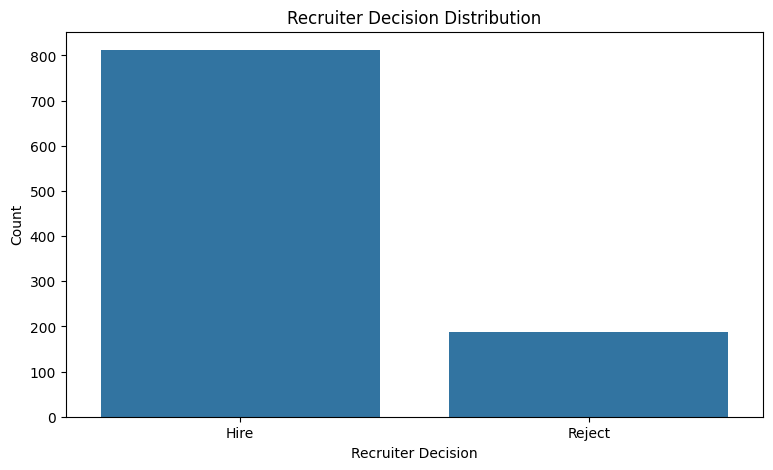

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(9,5))
sns.countplot(data=df , x='Recruiter Decision')
plt.xlabel('Recruiter Decision')
plt.ylabel('Count')
plt.title('Recruiter Decision Distribution')
plt.show()

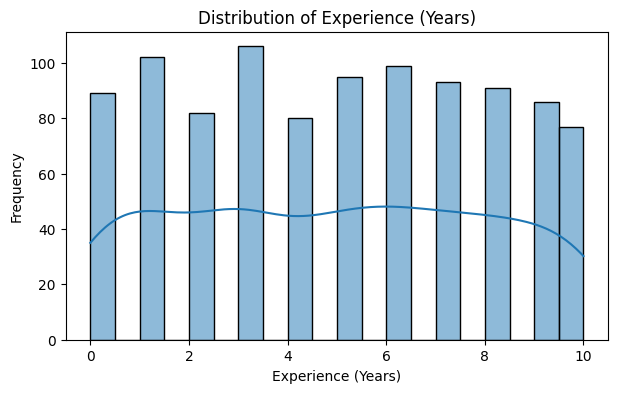

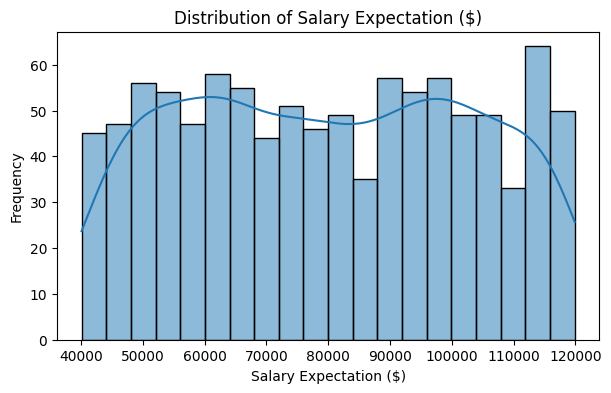

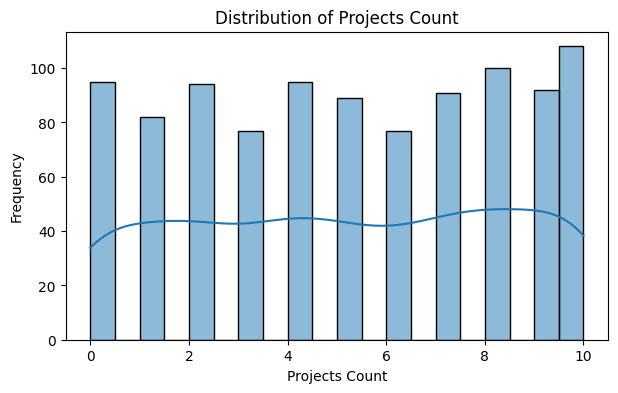

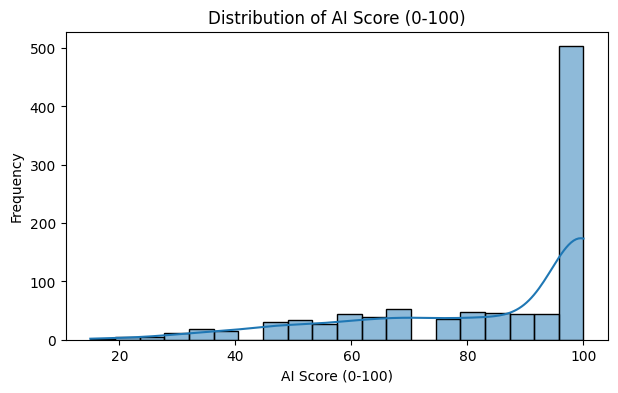

In [21]:
for col in numerical_cols:
    plt.figure(figsize=(7,4))

    sns.histplot(df[col], kde=True, bins=20)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

Correlation matrix

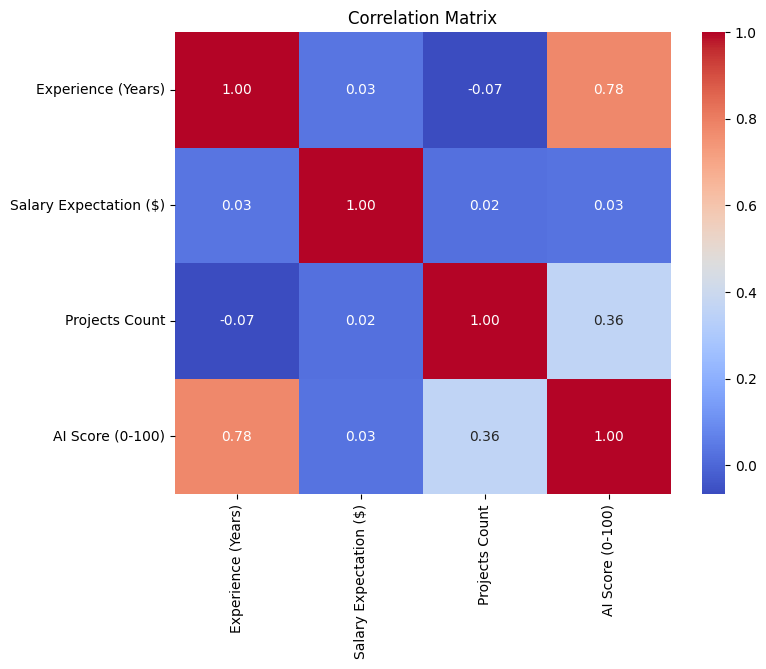

In [22]:
plt.figure(figsize=(8,6))

corr = df[numerical_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

Education field distribution

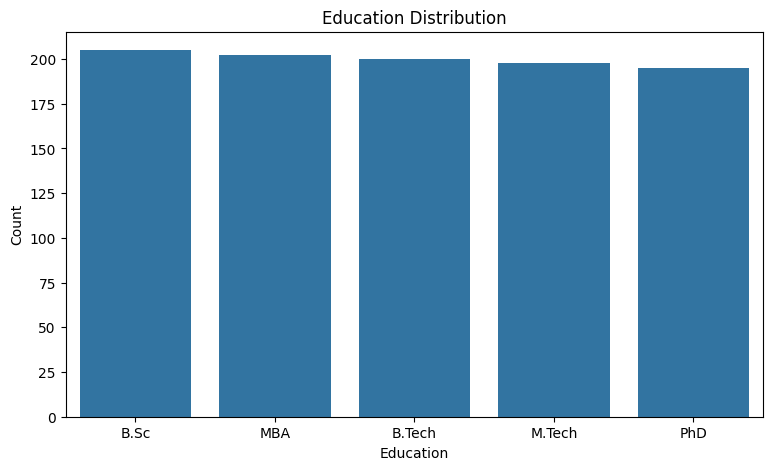

In [23]:
plt.figure(figsize=(9,5))
sns.countplot(data=df,x='Education',order=df['Education'].value_counts().index)
plt.xlabel('Education')
plt.ylabel('Count')
plt.title('Education Distribution')
plt.show()

Job Role distribution

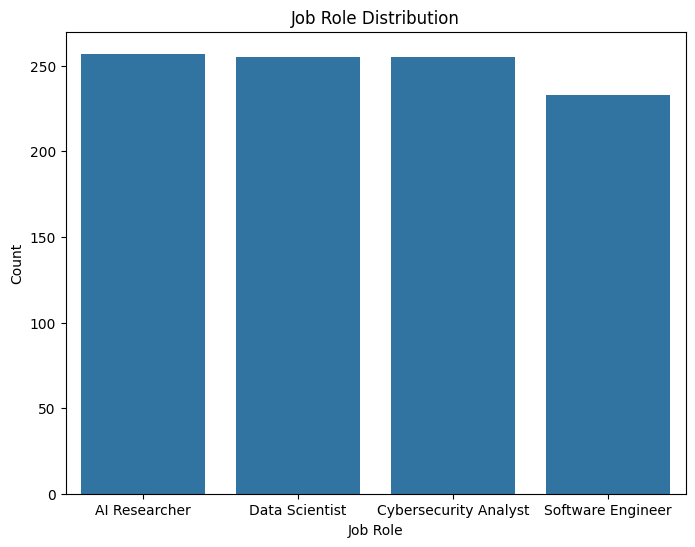

In [24]:
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='Job Role',order=df['Job Role'].value_counts().index)
plt.xlabel('Job Role')
plt.ylabel('Count')
plt.title('Job Role Distribution')
plt.show()

Certification Distribution

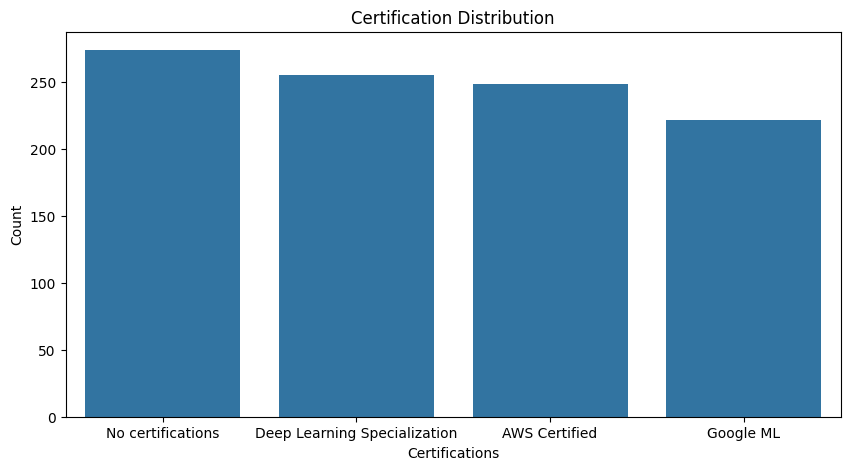

In [26]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Certifications',order=df['Certifications'].value_counts().index)
plt.xlabel('Certifications')
plt.ylabel('Count')
plt.title('Certification Distribution')
plt.show()

Checking outliers

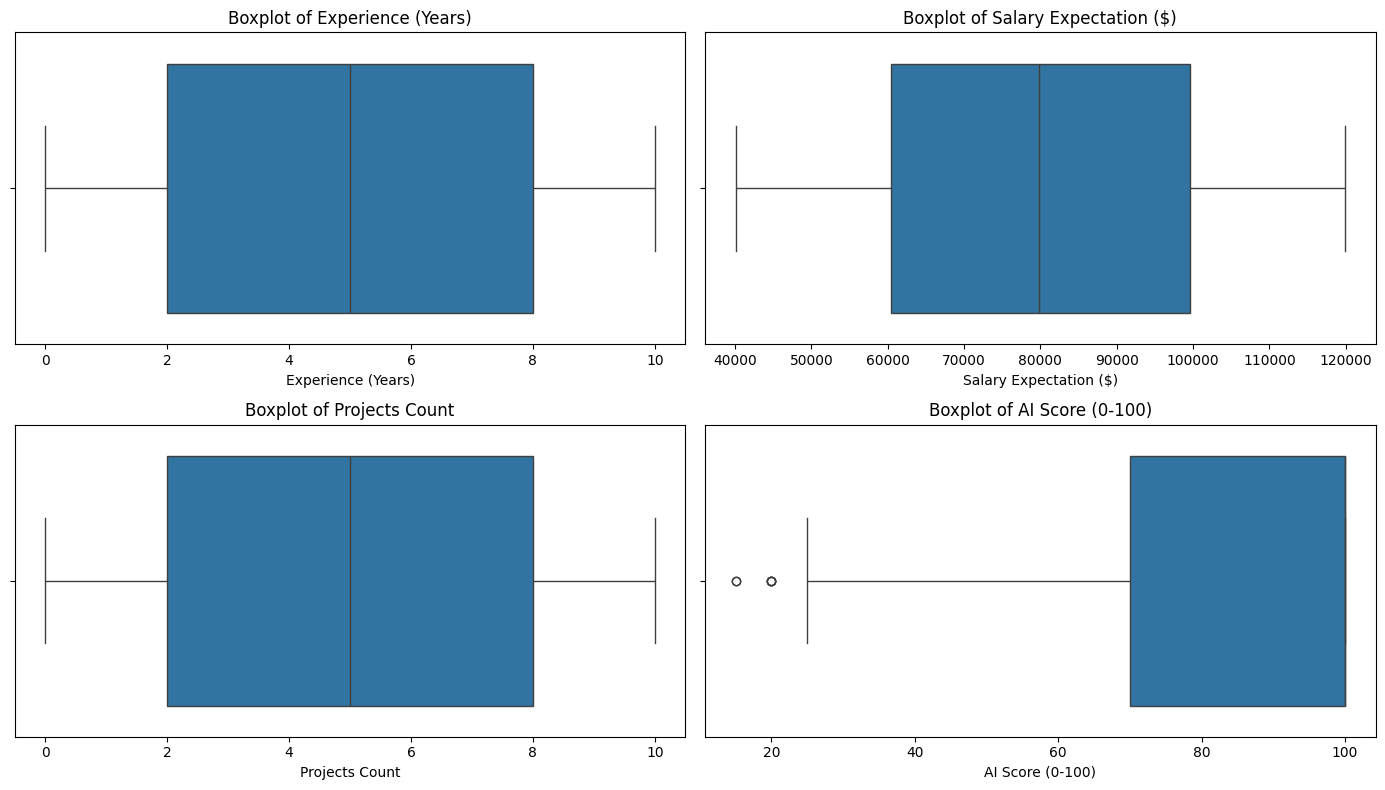

In [57]:
# Remove Resume_ID if it's still in numerical_cols
if "Resume_ID" in numerical_cols:
    numerical_cols.remove("Resume_ID")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [58]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Experience (Years): 0 outliers
Salary Expectation ($): 0 outliers
Projects Count: 0 outliers
AI Score (0-100): 6 outliers


Comparision of various fields with recruiter decision checking how each field affects the recruiter decision

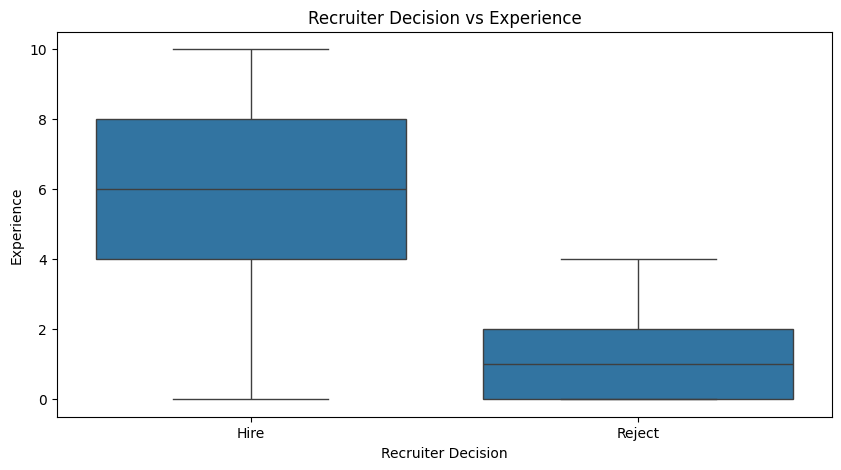

In [29]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df,x='Recruiter Decision',y='Experience (Years)')
plt.xlabel('Recruiter Decision')
plt.ylabel('Experience')
plt.title('Recruiter Decision vs Experience')
plt.show()

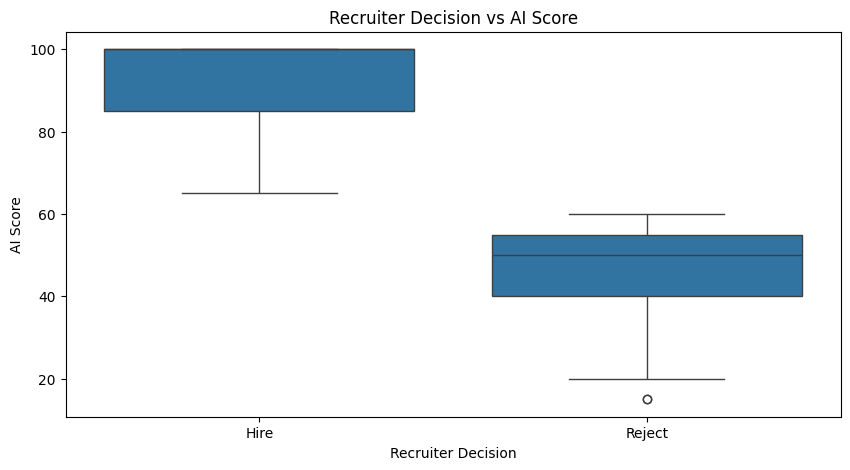

In [30]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df,x='Recruiter Decision',y='AI Score (0-100)')
plt.xlabel('Recruiter Decision')
plt.ylabel('AI Score')
plt.title('Recruiter Decision vs AI Score')
plt.show()

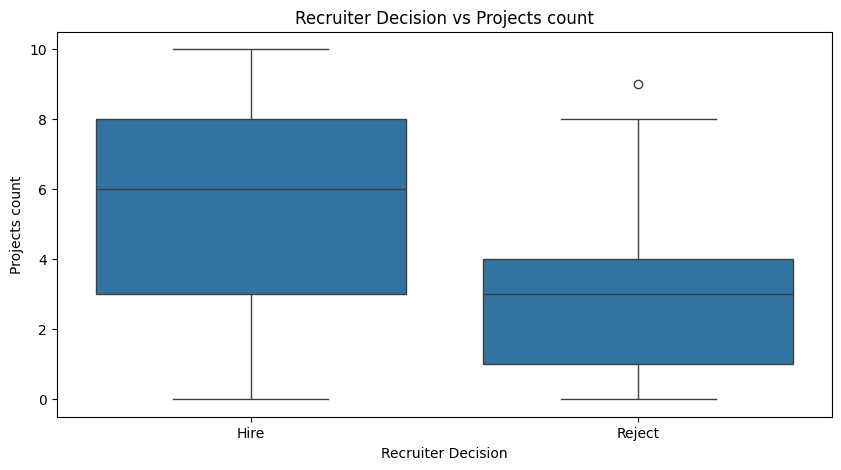

In [31]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df,x='Recruiter Decision',y='Projects Count')
plt.xlabel('Recruiter Decision')
plt.ylabel('Projects count')
plt.title('Recruiter Decision vs Projects count')
plt.show()

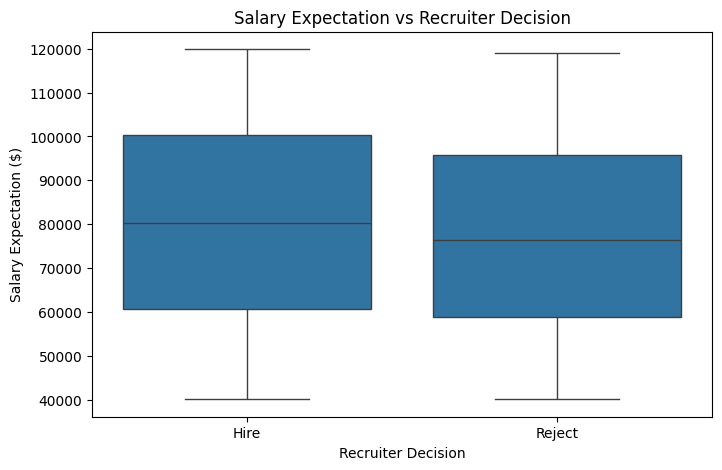

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Recruiter Decision",
    y="Salary Expectation ($)"
)

plt.title("Salary Expectation vs Recruiter Decision")
plt.show()

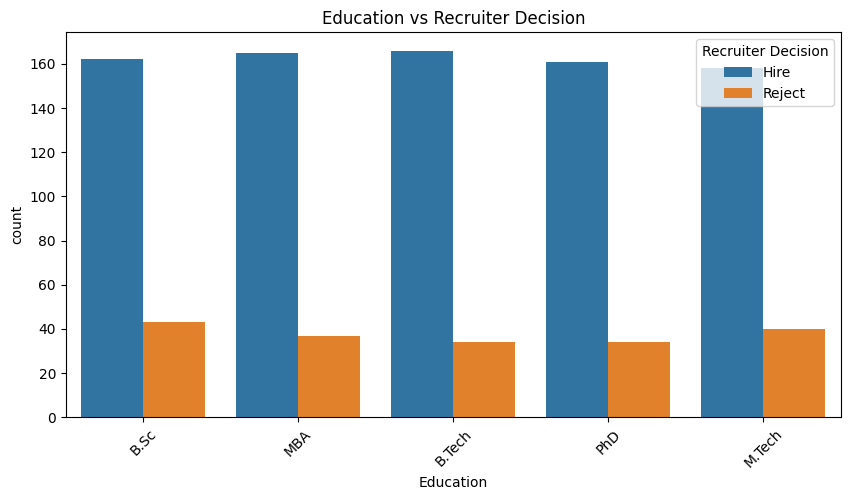

In [33]:
plt.figure(figsize=(10,5))

sns.countplot(data=df,x="Education",hue="Recruiter Decision")

plt.title("Education vs Recruiter Decision")
plt.xticks(rotation=45)

plt.show()

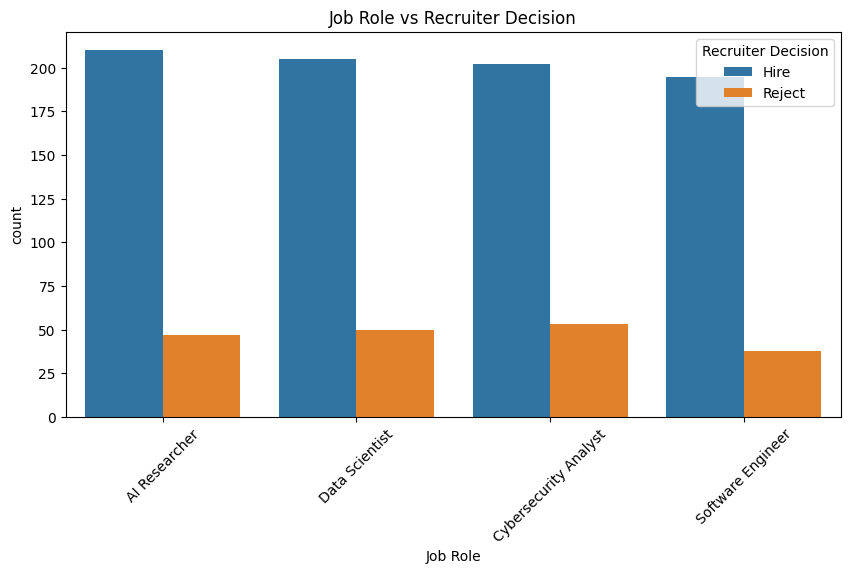

In [34]:
plt.figure(figsize=(10,5))

sns.countplot(data=df,x="Job Role",hue="Recruiter Decision")

plt.title("Job Role vs Recruiter Decision")
plt.xticks(rotation=45)

plt.show()


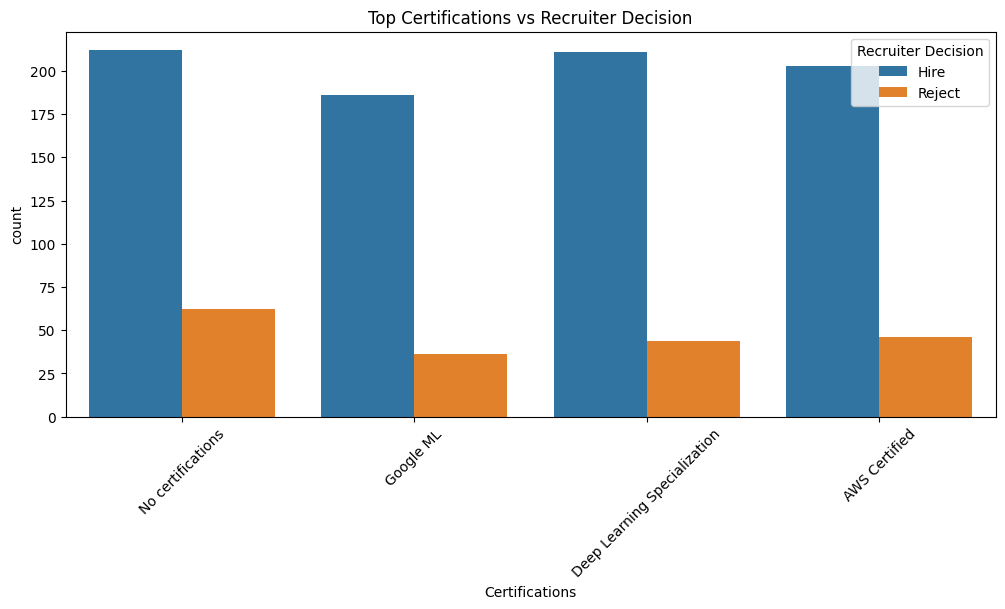

In [35]:
plt.figure(figsize=(12,5))

top_certifications = df["Certifications"].value_counts().head(10).index

sns.countplot(
    data=df[df["Certifications"].isin(top_certifications)],
    x="Certifications",
    hue="Recruiter Decision"
)

plt.title("Top Certifications vs Recruiter Decision")
plt.xticks(rotation=45)

plt.show()

##Working with data including AI_score

#Data preprocessing with AI-SCORE

In [36]:
df=df.drop(columns=['Resume_ID','Name'])

Feature and target value selection

In [37]:
X=df.drop(columns=['Recruiter Decision'],axis=1)
y=df['Recruiter Decision']
print(X.dtypes)

Skills                    object
Experience (Years)         int64
Education                 object
Certifications            object
Job Role                  object
Salary Expectation ($)     int64
Projects Count             int64
AI Score (0-100)           int64
dtype: object


Encoding target value

In [38]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)
print(y)


[0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 1 1 0 0 0 0 0 0 1 0 0 0 1 0 1 1 0
 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0
 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0
 0 1 1 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1
 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1
 0 0 0 0 1 1 0 1 0 0 0 1 1 1 0 0 0 1 0 0 1 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0 1 0 1 1 0 1 0 0 0 0 0 1 1 0 0 1 0 0 1 0 0 0
 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 1 0 0 0
 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 1 1
 0 0 0 0 0 0 0 0 0 0 0 0 

In [39]:
X = X.drop(columns=["Skills"])

One hot encoding

In [40]:
X=pd.get_dummies(X , columns=["Education", "Certifications", "Job Role"],drop_first=True)
print(X.head())

   Experience (Years)  Salary Expectation ($)  Projects Count  \
0                  10                  104895               8   
1                  10                  113002               1   
2                   1                   71766               7   
3                   7                   46848               0   
4                   4                   87441               9   

   AI Score (0-100)  Education_B.Tech  Education_M.Tech  Education_MBA  \
0               100             False             False          False   
1               100             False             False           True   
2                70             False             False           True   
3                95              True             False          False   
4               100             False             False          False   

   Education_PhD  Certifications_Deep Learning Specialization  \
0          False                                        False   
1          False                  

Train test split data

In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(800, 14)
(200, 14)


Standard scaling the features

In [43]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train[numerical_cols]=sc.fit_transform(X_train[numerical_cols])
X_test[numerical_cols]=sc.transform(X_test[numerical_cols])

In [60]:
print(X_train.columns.tolist())

['Experience (Years)', 'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)', 'Education_B.Tech', 'Education_M.Tech', 'Education_MBA', 'Education_PhD', 'Certifications_Deep Learning Specialization', 'Certifications_Google ML', 'Certifications_No certifications', 'Job Role_Cybersecurity Analyst', 'Job Role_Data Scientist', 'Job Role_Software Engineer']


#Model Training with AI score included

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay)
print("Model training necessary data imported")

Model training necessary data imported


Logistic Regression

0.995
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       154
           1       0.98      1.00      0.99        46

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



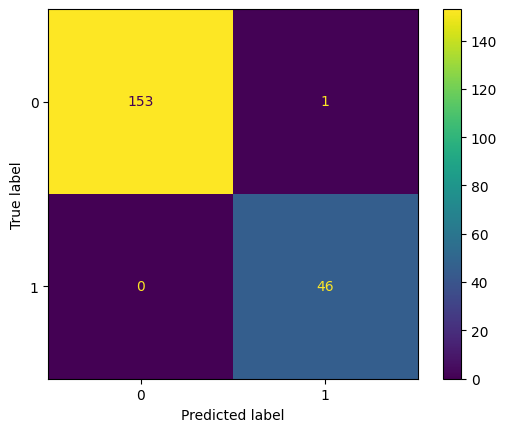

In [48]:
lg=LogisticRegression()
lg.fit(X_train,y_train)
y_pred_lr=lg.predict(X_test)
print(accuracy_score(y_test,y_pred_lr))
print(classification_report(y_test,y_pred_lr))
cm = confusion_matrix(y_test, y_pred_lr)

ConfusionMatrixDisplay(cm).plot()
plt.show()

Decision tree

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       154
           1       1.00      1.00      1.00        46

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



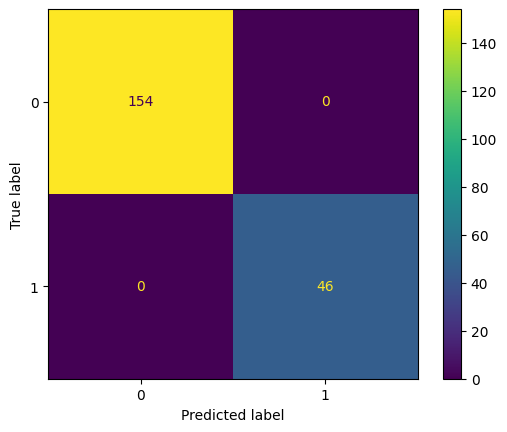

In [49]:
dt=DecisionTreeClassifier()
dt.fit(X_train,y_train)
y_pred_dt=dt.predict(X_test)
print(accuracy_score(y_test,y_pred_dt))
print(classification_report(y_test,y_pred_dt))
cm = confusion_matrix(y_test, y_pred_dt)

ConfusionMatrixDisplay(cm).plot()
plt.show()

Random forest

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       154
           1       1.00      1.00      1.00        46

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



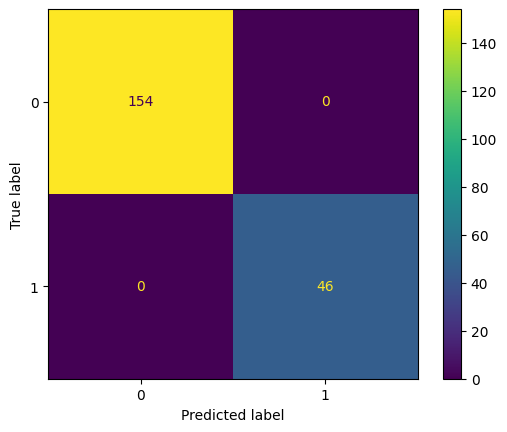

In [50]:
rf=RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_test)
print(accuracy_score(y_test,y_pred_rf))
print(classification_report(y_test,y_pred_rf))
cm = confusion_matrix(y_test, y_pred_rf)

ConfusionMatrixDisplay(cm).plot()
plt.show()

Gradient Boosting

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       154
           1       1.00      1.00      1.00        46

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



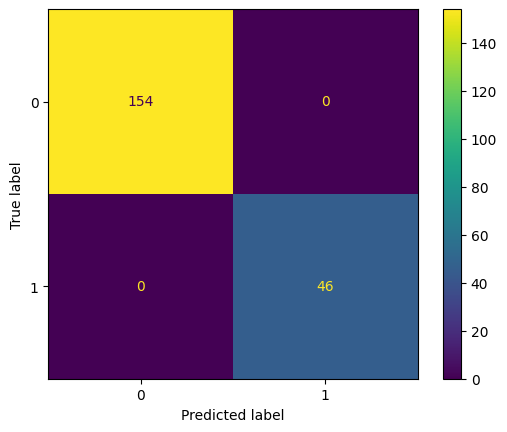

In [52]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test,y_pred_gb))
cm = confusion_matrix(y_test, y_pred_gb)

ConfusionMatrixDisplay(cm).plot()
plt.show()

xgboost

In [53]:
!pip install xgboost

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       154
           1       1.00      1.00      1.00        46

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



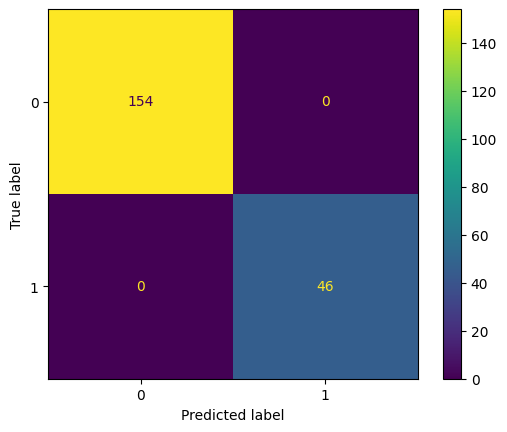

In [55]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print("Accuracy:",accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test,y_pred_xgb))
cm = confusion_matrix(y_test, y_pred_xgb)

ConfusionMatrixDisplay(cm).plot()
plt.show()

In [59]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_xgb)
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
1,Decision Tree,1.000
3,Gradient Boosting,1.000
2,Random Forest,1.000
4,XGBoost,1.000
0,Logistic Regression,0.995


In [61]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_})

feature_importance = feature_importance.sort_values(by="Importance",ascending=False)

print(feature_importance.head(10))

                                        Feature  Importance
3                              AI Score (0-100)    0.669350
0                            Experience (Years)    0.201515
2                                Projects Count    0.070552
1                        Salary Expectation ($)    0.028621
10             Certifications_No certifications    0.004113
12                      Job Role_Data Scientist    0.003560
8   Certifications_Deep Learning Specialization    0.003527
7                                 Education_PhD    0.003084
9                      Certifications_Google ML    0.002829
11               Job Role_Cybersecurity Analyst    0.002803


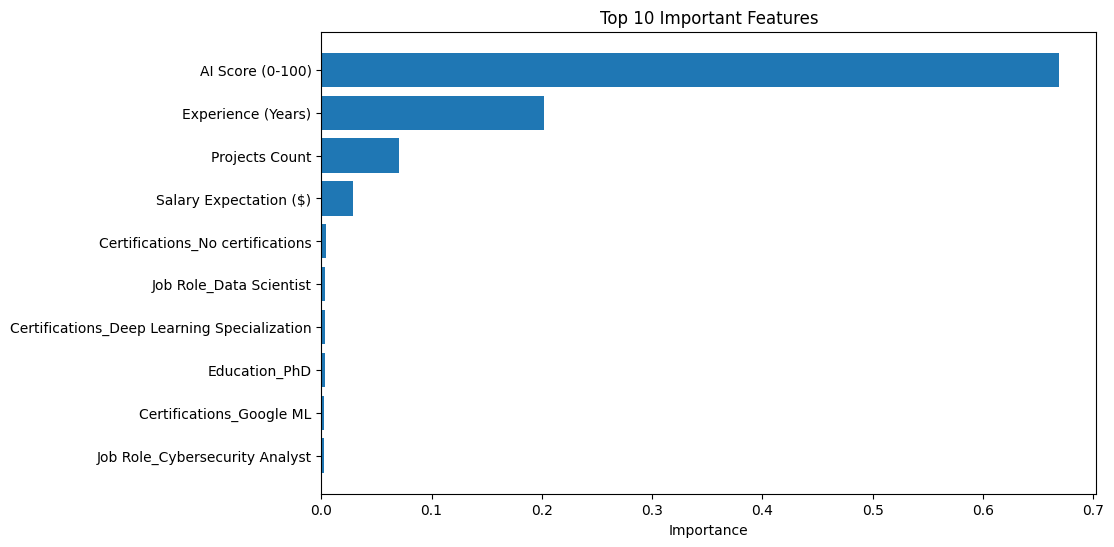

In [62]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],feature_importance["Importance"][:10])

plt.title("Top 10 Important Features")
plt.xlabel("Importance")

plt.gca().invert_yaxis()
plt.show()

#Hyperparameter tuning

In [63]:
from sklearn.model_selection import GridSearchCV

# Create the model
rf = RandomForestClassifier(random_state=42)

# Parameters to test
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

# Train
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:")
print(grid_search.best_params_)

# Best score
print("\nBest Cross Validation Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}

Best Cross Validation Accuracy:
1.0


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       154
           1       1.00      1.00      1.00        46

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



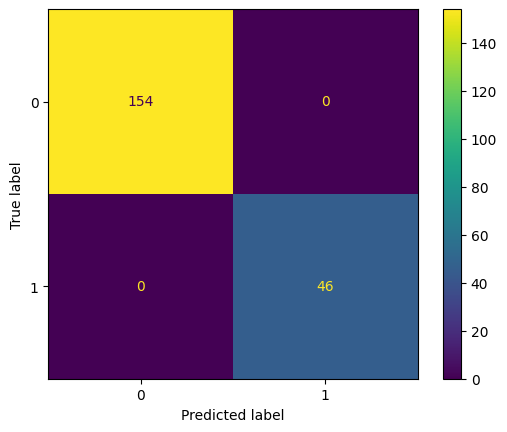

In [64]:
best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
print("Accuracy:",accuracy_score(y_test, y_pred_best_rf))
print(classification_report(y_test,y_pred_best_rf))
cm = confusion_matrix(y_test, y_pred_best_rf)

ConfusionMatrixDisplay(cm).plot()
plt.show()

Prediction

In [70]:
new_candidate = pd.DataFrame({
    "Experience (Years)": [5],
    "Salary Expectation ($)": [80000],
    "Projects Count": [7],
    "AI Score (0-100)": [90],
    "Education_B.Tech": [1],
    "Education_M.Tech": [0],
    "Education_MBA": [0],
    "Education_PhD": [0],
    "Certifications_Deep Learning Specialization": [1],
    "Certifications_Google ML": [0],
    "Certifications_No certifications": [0],
    "Job Role_Cybersecurity Analyst": [0],
    "Job Role_Data Scientist": [1],
    "Job Role_Software Engineer": [0]
})
numerical_features = [
    "Experience (Years)",
    "Salary Expectation ($)",
    "Projects Count",
    "AI Score (0-100)"
]
new_candidate[numerical_features] = sc.transform(
    new_candidate[numerical_features]
)
prediction = best_rf.predict(new_candidate)

print("Prediction:", le.inverse_transform(prediction)[0])

Prediction: Hire


##Working with data without including AI_Score

Data preprocessing without ai_score

In [75]:
X1 = df.drop(["Recruiter Decision", "AI Score (0-100)"], axis=1)
y1 = df["Recruiter Decision"]

In [76]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y1 = label_encoder.fit_transform(y1)

In [77]:
X1 = pd.get_dummies(
    X1,
    columns=["Education", "Certifications", "Job Role"],
    drop_first=True
)

In [82]:
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1,
    y1,
    test_size=0.2,
    random_state=42,
    stratify=y1
)

In [83]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_features = [
    "Experience (Years)",
    "Salary Expectation ($)",
    "Projects Count"
]

X1_train[numerical_features] = scaler.fit_transform(
    X1_train[numerical_features]
)

X1_test[numerical_features] = scaler.transform(
    X1_test[numerical_features]
)

#Model training removing AI_Score

Logistic regression

In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Drop 'Skills' column if it exists in X1_train and X1_test
if 'Skills' in X1_train.columns:
    X1_train = X1_train.drop(columns=['Skills'])
if 'Skills' in X1_test.columns:
    X1_test = X1_test.drop(columns=['Skills'])

lr1 = LogisticRegression(random_state=42)

lr1.fit(X1_train, y1_train)

y1_pred_lr = lr1.predict(X1_test)
print("Accuracy:", accuracy_score(y1_test, y1_pred_lr))

Accuracy: 0.97


Decision tree

In [86]:
from sklearn.tree import DecisionTreeClassifier
dt1 = DecisionTreeClassifier(random_state=42)
dt1.fit(X1_train, y1_train)
y1_pred_dt = dt1.predict(X1_test)
print("Accuracy:", accuracy_score(y1_test, y1_pred_dt))

Accuracy: 0.97


Random forest

In [87]:
from sklearn.ensemble import RandomForestClassifier
rf1 = RandomForestClassifier(random_state=42)
rf1.fit(X1_train, y1_train)
y1_pred_rf = rf1.predict(X1_test)
print("Accuracy:", accuracy_score(y1_test, y1_pred_rf))

Accuracy: 0.94


Gradient boosting

In [88]:
from sklearn.ensemble import GradientBoostingClassifier
gb1 = GradientBoostingClassifier(random_state=42)
gb1.fit(X1_train, y1_train)
y1_pred_gb = gb1.predict(X1_test)
print("Accuracy:", accuracy_score(y1_test, y1_pred_gb))

Accuracy: 0.965


XGBoost

In [89]:
from xgboost import XGBClassifier
xgb1 = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)
xgb1.fit(X1_train, y1_train)
y1_pred_xgb = xgb1.predict(X1_test)
print("Accuracy:", accuracy_score(y1_test, y1_pred_xgb))

Accuracy: 0.97


Models comperision

In [90]:
import pandas as pd

results1 = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y1_test, y1_pred_lr),
        accuracy_score(y1_test, y1_pred_dt),
        accuracy_score(y1_test, y1_pred_rf),
        accuracy_score(y1_test, y1_pred_gb),
        accuracy_score(y1_test, y1_pred_xgb)
    ]
})

results1.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
0,Logistic Regression,0.970
1,Decision Tree,0.970
4,XGBoost,0.970
3,Gradient Boosting,0.965
2,Random Forest,0.940


In [92]:
import pandas as pd

new_candidate = pd.DataFrame({
    "Experience (Years)": [5],
    "Salary Expectation ($)": [70000],
    "Projects Count": [6],

    "Education_B.Tech": [1],
    "Education_M.Tech": [0],
    "Education_MBA": [0],
    "Education_PhD": [0],

    "Certifications_Deep Learning Specialization": [1],
    "Certifications_Google ML": [0],
    "Certifications_No certifications": [0],

    "Job Role_Cybersecurity Analyst": [0],
    "Job Role_Data Scientist": [1],
    "Job Role_Software Engineer": [0]
})
numerical_features = [
    "Experience (Years)",
    "Salary Expectation ($)",
    "Projects Count"
]

new_candidate[numerical_features] = scaler.transform(
    new_candidate[numerical_features]
)
prediction = rf1.predict(new_candidate)

print("Prediction:", label_encoder.inverse_transform(prediction)[0])

Prediction: Hire


In [94]:
import joblib

# Save the model
joblib.dump(xgb1, "hiring_prediction_model.pkl")

# Save the scaler
joblib.dump(scaler, "scaler.pkl")

# Save the label encoder
joblib.dump(label_encoder, "label_encoder.pkl")

print("Model, Scaler, and Label Encoder saved successfully!")

Model, Scaler, and Label Encoder saved successfully!
